In [1]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import Caltech101
from PIL import Image

def load_image(image_path):
    img = Image.open(image_path)
    if img.mode != "RGB":
        img = img.convert("RGB")  # caltech101数据集中存在灰度图片，统一转换成 RGB
    return img

class ConvertToRGB:
    def __call__(self, img):
        return img.convert("RGB") if img.mode != "RGB" else img

transform = transforms.Compose([
    ConvertToRGB(),  
    transforms.Resize((224, 224)),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# 加载数据集
trainset = Caltech101(root="./data", download=True, transform=transform)
testset = Caltech101(root="./data", download=True, transform=transform)

# 生成 DataLoader
trainloader = DataLoader(trainset, batch_size=32, shuffle=True,num_workers=2)
testloader = DataLoader(testset, batch_size=32, shuffle=False,num_workers=2)

# 获取类别数
num_classes = len(trainset.categories)
print(f"Caltech-101 共有 {num_classes} 个类别")

Files already downloaded and verified
Files already downloaded and verified
Caltech-101 共有 101 个类别


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


[5967, 7880, 2183, 2531, 5176, 8671, 3871, 3799, 2526]


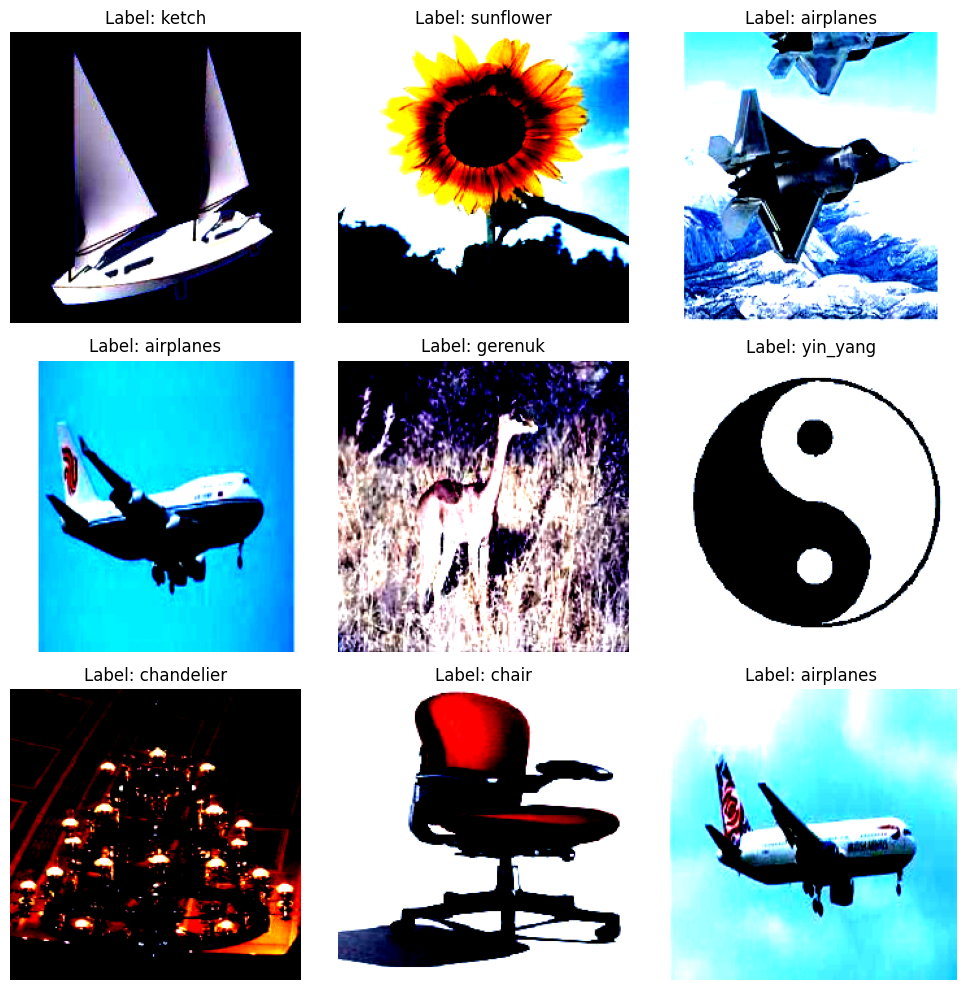

In [4]:
import random
import matplotlib.pyplot as plt

# 可视化数据集样本
def visualize_samples(dataset, num_samples=9):
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))

    # 随机选择 num_samples 张图片
    indices = random.sample(range(len(dataset)), num_samples)
    print(indices)
    for i, idx in enumerate(indices):
        image, label = dataset[idx]
        ax = axes[i // 3, i % 3]

        # [c,h,w]->[h,w,c]
        image = image.permute(1, 2, 0).numpy()

        # 显示图片
        ax.imshow(image)
        ax.set_title(f"Label: {dataset.categories[label]}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# 调用可视化函数
visualize_samples(trainset)


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# 加载预训练的ResNet-18模型
model = models.resnet18(pretrained=True)

# 修改最后一层，以适应CIFAR-10的10个类别
model.fc = nn.Linear(model.fc.in_features, num_classes)

# 将模型移动到GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.001)

# 训练模型
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader)}")


/media/nvme1n1p1/users/xiaokun1/miniconda3/envs/applet/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
/media/nvme1n1p1/users/xiaokun1/miniconda3/envs/applet/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1, Loss: 2.2863121067776397
Epoch 2, Loss: 0.7710200342185357
Epoch 3, Loss: 0.39048001170158386
Epoch 4, Loss: 0.2396535906009376
Epoch 5, Loss: 0.16324197825537445
Epoch 6, Loss: 0.11950430024743956
Epoch 7, Loss: 0.08892846830627497
Epoch 8, Loss: 0.07523903922479161
Epoch 9, Loss: 0.06043871903709848
Epoch 10, Loss: 0.04912896976833615


In [6]:
# 保存model
torch.save(model, "res18_model_best.pth")

In [6]:
# 加载model
import torch
model = torch.load("res18_model_best.pth")
# 将模型移动到GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [23]:
def evaluate_model(model, testloader, device):
    model.eval()  # 设置为评估模式
    correct = 0
    total = 0

    with torch.no_grad():  # 禁用梯度计算，加快推理速度
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            _, predicted = torch.max(outputs, 1)  # 取最大概率的类别
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"模型在测试集上的准确率: {accuracy:.2f}%")
    return accuracy

# 调用测试函数
evaluate_model(model, testloader, device)

模型在测试集上的准确率: 99.92%


99.91932695632131

vis **Faces** image:./data/caltech101/101_ObjectCategories/Faces/image_0288.jpg


/media/nvme1n1p1/users/xiaokun1/miniconda3/envs/applet/lib/python3.10/site-packages/torch/nn/modules/module.py:1053: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "


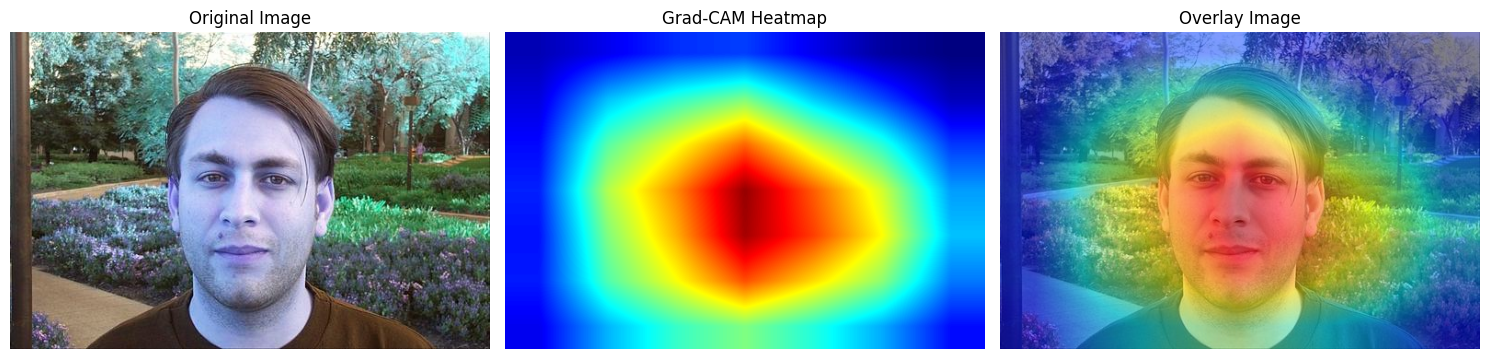

In [7]:
import cv2
import os
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model: nn.Module, target_layer: str, size=(224, 224), mean=None, std=None) -> None:
        self.model = model
        self.model.eval()
        
        # register hook
        # 可以自己指定层名，没必要一定通过target_layer传递参数
        # self.model.layer4
        # self.model.layer4[1].register_forward_hook(self.__forward_hook)
        # self.model.layer4[1].register_backward_hook(self.__backward_hook)
        getattr(self.model, target_layer).register_forward_hook(self.__forward_hook)
        getattr(self.model, target_layer).register_backward_hook(self.__backward_hook)

        self.size = size
        self.origin_size = None
        self.mean, self.std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
        if mean and std:
            self.mean, self.std = mean, std

        self.grads = []
        self.fmaps = []

    def forward(self, img_arr: np.ndarray, label=None, show=True, write=False):
        img_input = self.__img_preprocess(img_arr.copy())

        # forward
        output = self.model(img_input)
        idx = np.argmax(output.cpu().data.numpy())

        # backward
        self.model.zero_grad()
        loss = self.__compute_loss(output, label)

        loss.backward()

        # generate CAM
        grads_val = self.grads[0].cpu().data.numpy().squeeze()
        fmap = self.fmaps[0].cpu().data.numpy().squeeze()
        cam = self.__compute_cam(fmap, grads_val)
        
        # show
        cam_show = cv2.resize(cam, self.origin_size)
        img_show = img_arr.astype(np.float32) / 255
        self.__show_cam_on_image(img_show, cam_show, if_show=show, if_write=write)

        self.fmaps.clear()
        self.grads.clear()
        
    def __img_transform(self, img_arr: np.ndarray, transform: torchvision.transforms) -> torch.Tensor:
        img = img_arr.copy()  # [H, W, C]
        img = Image.fromarray(np.uint8(img))
        img = transform(img).unsqueeze(0)  # [N,C,H,W]
        return img

    def __img_preprocess(self, img_in: np.ndarray) -> torch.Tensor:
        self.origin_size = (img_in.shape[1], img_in.shape[0])  # [H, W, C]
        img = img_in.copy()
        img = cv2.resize(img, self.size)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(self.mean, self.std)
        ])
        img_tensor = self.__img_transform(img, transform)
        return img_tensor.to(device)

    def __backward_hook(self, module, grad_in, grad_out):
        self.grads.append(grad_out[0].detach())
    
    def __forward_hook(self, module, input, output):
        self.fmaps.append(output)

    def __compute_loss(self, logit, index=None):
        if not index:
            index = np.argmax(logit.cpu().data.numpy())
        else:
            index = np.array(index)

        index = index[np.newaxis, np.newaxis]
        index = torch.from_numpy(index)
        one_hot = torch.zeros(1, num_classes).scatter_(1, index, 1).to(device)
        one_hot.requires_grad = True
        loss = torch.sum(one_hot * logit)
        return loss
    
    def __compute_cam(self, feature_map, grads):
        """
        feature_map: np.array [C, H, W]
        grads: np.array, [C, H, W]
        return: np.array, [H, W]
        """
        cam = np.zeros(feature_map.shape[1:], dtype=np.float32)
        alpha = np.mean(grads, axis=(1, 2))  # GAP
        for k, ak in enumerate(alpha):
            cam += ak * feature_map[k]  # linear combination
        
        cam = np.maximum(cam, 0)  # relu
        cam = cv2.resize(cam, self.size)
        cam = (cam - np.min(cam)) / np.max(cam)
        return cam


    def __show_cam_on_image(self, img: np.ndarray, mask: np.ndarray, if_show=True, if_write=False):
        heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
        heatmap = np.float32(heatmap) / 255
        cam = heatmap + np.float32(img)
        cam = cam / np.max(cam)
        cam = np.uint8(255 * cam)
        if if_write:
            cv2.imwrite("camcam.jpg", cam)
        if if_show:
            # 要显示RGB的图片，如果是BGR的 热力图是反过来的
            # img
            # plt.imshow(cam[:, :, ::-1])
            # 使用 plt 可视化
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            
            axes[0].imshow(img)
            axes[0].set_title("Original Image")
            axes[0].axis("off")

            axes[1].imshow(heatmap[:, :, ::-1])
            axes[1].set_title("Grad-CAM Heatmap")
            axes[1].axis("off")

            axes[2].imshow(cam[:, :, ::-1])
            axes[2].set_title("Overlay Image")
            axes[2].axis("off")

            plt.tight_layout()
            plt.show()

# 调用函数
index = 287
image, label = testset[index]
image_path=os.path.join(
                testset.root,
                "101_ObjectCategories",
                testset.categories[testset.y[index]],
                f"image_{testset.index[index]:04d}.jpg",
            )
print(f"vis **{testset.categories[testset.y[index]]}** image:{image_path}")
img = cv2.imread(image_path, 1)

grad_cam = GradCAM(model, 'layer4', (224, 224), [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
grad_cam.forward(img, show=True, write=False)